In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Layer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import glob
import os
import csv
import shutil
import time


In [2]:
# --- Mixed precision for performance ---
#mixed_precision.set_global_policy('mixed_float16')
import os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent.parent #two folders DEEP
# --- Config ---
CONFIG = {
    "DATA_DIR": PROJECT_ROOT / "TrainingData/indicators_data/processed/stocksData",
    "FORECAST_DIR": PROJECT_ROOT / "forecasts",
    "CACHE_DIR": PROJECT_ROOT / "cache",
    "WINDOW_SIZE": 90,
    "TRAIN_VAL_FRAC": 0.8,
    "VAL_FRAC_WITHIN_TRAIN": 0.2,
    "MC_DROPOUT_SAMPLES": 25,
    "EXCLUDED_COLS": ["date", "Target_1d", "Target_1w", "Target_1m", "Target_6m"],
    "PROB_THRESHOLD": 0.7,
}
'''To determine the "best" return treshold for a BUY, 
I will create a new function that looks at the average, 1d, 1w, 1m, 6m returns
for the entire data set, and then we can later set the threshold return at 
some multiple (2x or 3x) of that average return. This avoids guessing a treshold return,
and then by change the selected stocks have a much higher return than this.
We want our model to overperform, don't we!? '''
#For the binary classification: BUY (1) if the return is above the target

#CONFIG["CLASS_THRESHOLD"] = {
#    "Target_1d": -0.801,
#    "Target_1w": -0.801, 
#    "Target_1m": -0.801,
#    "Target_6m": -0.801
#}

horizons = ["1d", "1w", "1m", "6m"]
horizon_days = [1, 5, 21, 126]

In [3]:
# Ensure dirs exist
CONFIG["FORECAST_DIR"].mkdir(exist_ok=True)
CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

# --- Globals ---
scaler = StandardScaler()
feature_cols = None

In [4]:
# --- MC Dropout ---
class MCDropout(Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

def mc_dropout_predict(model, X, n_samples=50):
    preds = np.array([model(X, training=True).numpy() for _ in range(n_samples)])
    return preds.mean(axis=0), preds.std(axis=0), preds

In [5]:
def add_raw_returns(df):
    df["LogR_1d"] = np.log(df["close"].shift(-1) / df["close"])
    df["LogR_1w"] = np.log(df["close"].shift(-5) / df["close"])
    df["LogR_1m"] = np.log(df["close"].shift(-21) / df["close"])
    df["LogR_6m"] = np.log(df["close"].shift(-126) / df["close"])
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df


In [6]:
# --- Data processing helpers ---
def add_features(df):
    df = add_raw_returns(df)  # compute LogR again or reuse

    df["Target_1d"] = (df["LogR_1d"] > CONFIG["CLASS_THRESHOLD"]["Target_1d"]).astype(int)
    df["Target_1w"] = (df["LogR_1w"] > CONFIG["CLASS_THRESHOLD"]["Target_1w"]).astype(int)
    df["Target_1m"] = (df["LogR_1m"] > CONFIG["CLASS_THRESHOLD"]["Target_1m"]).astype(int)
    df["Target_6m"] = (df["LogR_6m"] > CONFIG["CLASS_THRESHOLD"]["Target_6m"]).astype(int)
    df = df.fillna(0)
    return df

''' 
Training with overlapping horizons presents over fitting issues. To avoid this,
we can use a max-horizon step of 126 days (6 trading months). We will create
a separate process_stock for inference when it comes time to do the prediction.
This will give us daily predictions rather than a prediction every 126 days.
'''
def process_stock(csv_path: Path, for_training=True):
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    df = add_features(df)
    if df.empty:
        return np.array([]), np.array([]), df, np.array([])

    global feature_cols
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    features_scaled = scaler.transform(df[feature_cols].values)
    dates = df["date"].values
    target = df[["Target_1d", "Target_1w", "Target_1m", "Target_6m"]].values if for_training else None

    X, y, y_dates = [], [], []
    window = CONFIG["WINDOW_SIZE"]
    max_horizon = max(horizon_days)#126 days,  6 trading months

    for i in range(window, len(features_scaled), max_horizon):
        X.append(features_scaled[i - window:i + 1])
        if for_training:
            y.append(target[i])
        y_dates.append(dates[i])

    return (
        np.array(X),
        np.array(y) if for_training else None,
        df,
        np.array(y_dates, dtype="datetime64[ns]"),
    )

In [7]:
def process_stock_for_inference(csv_path: Path):
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    df = add_features(df)
    if df.empty:
        return np.array([]), np.array([]), df, np.array([])

    global feature_cols
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    features_scaled = scaler.transform(df[feature_cols].values)
    dates = df["date"].values
    target = df[["close"]].values

    X, x_dates = [], []
    window = CONFIG["WINDOW_SIZE"]
    max_horizon = 1 

    for i in range(window, len(features_scaled), max_horizon):
        X.append(features_scaled[i - window:i + 1])
        x_dates.append(dates[i])

    return (
        np.array(X),
        df.loc[window:, "close"].values[:len(X)],
        np.array(x_dates, dtype="datetime64[ns]"),
        df
    )

In [8]:
# Cache preprocessed stock
def cache_preprocessed_stock(csv_path: Path, train_cutoff, train_val_cutoff):
    stock_name = csv_path.stem
    print(f"Rebuilding cache for: {stock_name}")

    X, y, _, y_dates = process_stock(csv_path, for_training=True)
    if X.size == 0:
        for split in ["train", "val", "test"]:
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", np.array([]))
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", np.array([]))
        return

    y_dates = pd.to_datetime(y_dates)
    splits = {
        "train": y_dates < np.datetime64(train_cutoff),
        "val": (y_dates >= np.datetime64(train_cutoff)) & (y_dates < np.datetime64(train_val_cutoff)),
        "test": y_dates >= np.datetime64(train_val_cutoff),
    }
    for split, mask in splits.items():
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", X[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", y[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{split}.npy", y_dates[mask])

    print(
        f"Cached {stock_name}: "
        + ", ".join([f"{s}={np.sum(m)}" for s, m in splits.items()])
    )

In [9]:
# --- Data generator ---
class StockDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, csv_paths, batch_size=512, split="train", shuffle=True, use_time_weights=True, decay_factor = 0.001):
        self.csv_paths = csv_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.split = split
        self.use_time_weights = use_time_weights
        self.decay_factor = decay_factor
        self.windows = []
        self.stock_names = [Path(p).stem for p in csv_paths]
        self._prepare_indices()
        self.on_epoch_end()

    def _prepare_indices(self):
        self.windows = []
        self.lengths = {}
        self.date_arrays = {}
        for stock_name in self.stock_names:
            X_path = CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy"
            y_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy"
            date_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{self.split}.npy"
            if not X_path.exists():
                n_windows = 0
            else:
                X = np.load(X_path, mmap_mode="r")
                n_windows = len(X)
                if date_path.exists():
                    self.date_arrays[stock_name] = np.load(date_path, allow_pickle=True)
            self.lengths[stock_name] = n_windows
            for i in range(n_windows):
                self.windows.append((stock_name, i))
        self.indices = np.arange(len(self.windows))

    def __len__(self):
        return int(np.ceil(len(self.windows) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch, y_batch, weights_batch = [], [], []
        cache = {}
        for bi in batch_indices:
            stock_name, win_idx = self.windows[bi]
            if stock_name not in cache:
                X = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy", mmap_mode="r")
                y = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy", mmap_mode="r")
                cache[stock_name] = (X, y)
            X_arr, y_arr = cache[stock_name]
            X_batch.append(X_arr[win_idx])
            y_batch.append(y_arr[win_idx])

            if self.use_time_weights and stock_name in self.date_arrays:
                dates = self.date_arrays[stock_name]
                date = pd.to_datetime(dates[win_idx])
                #Give more weight to recent dates now
                date_ago = (pd.Timestamp.now() - date).days
                weights_batch.append(np.exp(-self.decay_factor * date_ago))
            else:
                weights_batch.append(1.0)



        if self.split == "val":
            return np.array(X_batch), np.array(y_batch)
        else:
            return np.array(X_batch), np.array(y_batch), np.array(weights_batch)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [10]:
def make_forecast(model, X, dates, closes, horizons, horizon_days):
    y_pred_mean, y_pred_std, _ = mc_dropout_predict(model, X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])
    df_dict = {"Date": dates, "Close": closes}

    for i, h in enumerate(horizons):
        df_dict[f"Pred_Prob_{h}"] = y_pred_mean[:, i]
        df_dict[f"Pred_Prob_Std_{h}"] = y_pred_std[:, i]   

        days = horizon_days[i]
        df_dict[f"Pred_Prob_PerDayStd_{h}"] = y_pred_std[:, i] / np.sqrt(days)

    forecasting_df = pd.DataFrame(df_dict)
    return forecasting_df

all_csvs = sorted(glob.glob(str(CONFIG["DATA_DIR"] / "*.csv")))
print(f"Found {len(all_csvs)} stocks")

Found 1688 stocks


In [11]:

global_min_date, global_max_date = None, None
feature_cols = None
scaler_inputs = []

RETS = {"1d": [], "1w": [], "1m": [], "6m": []}

for csv_path in all_csvs:
    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])

    if df.empty:
        continue

    # compute raw log returns (NO dropna)
    df = add_raw_returns(df)

    RETS["1d"].extend(df["LogR_1d"].dropna().tolist())
    RETS["1w"].extend(df["LogR_1w"].dropna().tolist())
    RETS["1m"].extend(df["LogR_1m"].dropna().tolist())
    RETS["6m"].extend(df["LogR_6m"].dropna().tolist())

    dmin = df["date"].min()
    dmax = df["date"].max()

    if global_min_date is None or dmin < global_min_date:
        global_min_date = dmin
    if global_max_date is None or dmax > global_max_date:
        global_max_date = dmax

# Define global cutoffs
total_span = (global_max_date - global_min_date).days

train_cutoff = global_min_date + pd.Timedelta(days=total_span * CONFIG["TRAIN_VAL_FRAC"])
val_cutoff   = global_min_date + pd.Timedelta(days=total_span * (CONFIG["TRAIN_VAL_FRAC"] + CONFIG["VAL_FRAC_WITHIN_TRAIN"]))

print("\nTrain/Val/Test cutoffs:")
print("Train cutoff:", train_cutoff)
print("Val cutoff:  ", val_cutoff)

# Compute dataset averages and stds
dataset_avg = {h: np.mean(RETS[h]) for h in RETS}
dataset_std = {h: np.std(RETS[h]) for h in RETS}

print("\nDataset Average Log Returns:")
for k, v in dataset_avg.items():
    print(f"{k}: {v:.6f}")

print("\nDataset Std Log Returns:")
for k, v in dataset_std.items():
    print(f"{k}: {v:.6f}")

# Classification thresholds
CONFIG["CLASS_THRESHOLD"] = {
    "Target_1d": dataset_avg["1d"] + 1.5*dataset_std["1d"],
    "Target_1w": dataset_avg["1w"] + 1.5*dataset_std["1w"],
    "Target_1m": dataset_avg["1m"] + 1.5*dataset_std["1m"],
    "Target_6m": dataset_avg["6m"] + 1.5*dataset_std["6m"],
}


Train/Val/Test cutoffs:
Train cutoff: 2020-09-22 00:00:00
Val cutoff:   2025-12-02 00:00:00

Dataset Average Log Returns:
1d: 0.000111
1w: 0.000540
1m: 0.002220
6m: 0.013953

Dataset Std Log Returns:
1d: 0.048942
1w: 0.098075
1m: 0.189278
6m: 0.428173


In [12]:
# Build classification targets and collect scaler inputs
for csv_path in all_csvs:
    df_raw = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date")
    df_raw = df_raw.dropna(subset=["date"])

    df = add_features(df_raw.copy())   # classification labels

    if df.empty:
        continue

    NON_FEATURES = [
        "date", "close",
        "LogR_1d", "LogR_1w", "LogR_1m", "LogR_6m",
        "Target_1d", "Target_1w", "Target_1m", "Target_6m"
    ]

    feat_cols = [c for c in df.columns if c not in NON_FEATURES]

    if feature_cols is None:
        feature_cols = feat_cols

    # scaler input from RAW DATAFRAME (not cleaned)
    train_rows = df[df["date"] < train_cutoff]
    if len(train_rows) > 0:
        scaler_inputs.append(train_rows[feat_cols].values)


In [13]:
if len(scaler_inputs) == 0:
    raise RuntimeError("No training data collected for scaler_inputs – check your date filters or input files.")

X = np.vstack(scaler_inputs)
X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
scaler.fit(X)
print("Fitted scaler. n_features:", X.shape[1])

Fitted scaler. n_features: 38


In [14]:
def safe_cache(all_csvs, train_cutoff, val_cutoff):
    start_time = time.time()
    max_seconds = 10
    while True:
        try:
            time.sleep(1)

            # Cache all data 
            if CONFIG["CACHE_DIR"].exists():
                shutil.rmtree(CONFIG["CACHE_DIR"])
            CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

            print("Caching all preprocessed stock data...")
            for csv_path in all_csvs:
                cache_preprocessed_stock(Path(csv_path), train_cutoff, val_cutoff)
            print("Done caching.")

            return
        except Exception as e:
            if time.time() - start_time > max_seconds:
                raise RuntimeError(f"Failed to cache")
            print('Retrying to cache...')
            print(e)
            time.sleep(1)

safe_cache(all_csvs, train_cutoff, val_cutoff)

Caching all preprocessed stock data...
Rebuilding cache for: AACG_daily_processed
Cached AACG_daily_processed: train=25, val=10, test=0
Rebuilding cache for: AAL_daily_processed
Cached AAL_daily_processed: train=29, val=11, test=0
Rebuilding cache for: AAME_daily_processed
Cached AAME_daily_processed: train=41, val=10, test=0
Rebuilding cache for: AAMI_daily_processed
Cached AAMI_daily_processed: train=5, val=10, test=0
Rebuilding cache for: AAOI_daily_processed
Cached AAOI_daily_processed: train=14, val=10, test=0
Rebuilding cache for: AAON_daily_processed
Cached AAON_daily_processed: train=41, val=11, test=0
Rebuilding cache for: AAPL_daily_processed
Cached AAPL_daily_processed: train=41, val=11, test=0
Rebuilding cache for: AAP_daily_processed
Cached AAP_daily_processed: train=37, val=10, test=0
Rebuilding cache for: AAT_daily_processed
Cached AAT_daily_processed: train=19, val=10, test=0
Rebuilding cache for: AA_daily_processed
Cached AA_daily_processed: train=7, val=11, test=0
Reb

KeyboardInterrupt: 

In [ ]:
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")        
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)  # attention weights
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [ ]:
# --- Data generators ---
train_gen = StockDataGenerator(all_csvs, batch_size=128, split="train", shuffle=True, use_time_weights=False, decay_factor=0.002)
val_gen = StockDataGenerator(all_csvs, batch_size=128, split="val", shuffle=False)

In [ ]:
#Actual training with the weights now
def generator_with_weights(gen):
    for X, y, w in gen:
        yield X, y, w

train_dataset = tf.data.Dataset.from_generator(
    lambda: generator_with_weights(train_gen),
    output_signature=(
        tf.TensorSpec(shape=(None, CONFIG["WINDOW_SIZE"] + 1, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: generator_with_weights(val_gen),
    output_signature=(
        tf.TensorSpec(shape=(None, CONFIG["WINDOW_SIZE"] + 1, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )
)

Epoch 1/500
320/320 [==============================] - 44s 133ms/step - loss: 0.1188 - accuracy: 0.1830 - val_loss: 0.1324 - val_accuracy: 0.2469
Epoch 2/500
320/320 [==============================] - 35s 109ms/step - loss: 0.0868 - accuracy: 0.2105 - val_loss: 0.1244 - val_accuracy: 0.4104
Epoch 3/500
320/320 [==============================] - 33s 105ms/step - loss: 0.0850 - accuracy: 0.2629 - val_loss: 0.1257 - val_accuracy: 0.3535
Epoch 4/500
320/320 [==============================] - 33s 104ms/step - loss: 0.0843 - accuracy: 0.2723 - val_loss: 0.1254 - val_accuracy: 0.1042
Epoch 5/500
320/320 [==============================] - 33s 103ms/step - loss: 0.0828 - accuracy: 0.2098 - val_loss: 0.1245 - val_accuracy: 0.3641
Epoch 6/500
320/320 [==============================] - 35s 110ms/step - loss: 0.0827 - accuracy: 0.3564 - val_loss: 0.1249 - val_accuracy: 0.3310
Epoch 7/500
320/320 [==============================] - 33s 104ms/step - loss: 0.0820 - accuracy: 0.2513 - val_loss: 0.1264 -

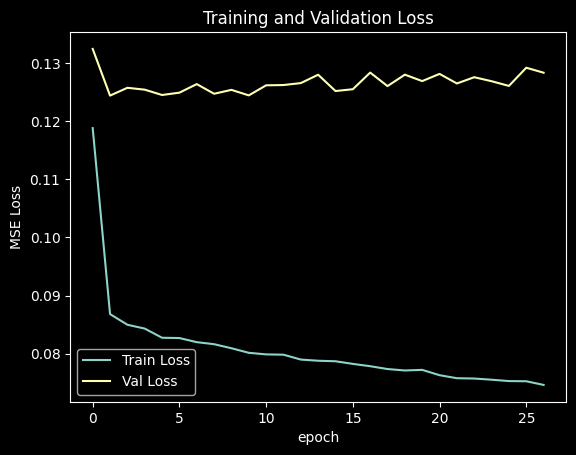

In [ ]:
n_features = len(feature_cols)
model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", 
           input_shape=(CONFIG["WINDOW_SIZE"] + 1, n_features)),
    BatchNormalization(),
    MCDropout(0.3),
    LSTM(64, return_sequences=False), 
    MCDropout(0.3),
    Dense(32, activation="relu"),
    Dense(4, activation="sigmoid") #Four time horizon predictions as output
])

early_stop = EarlyStopping(
    patience = 25,
    monitor = "val_loss",
    restore_best_weights = True,
    mode = "min",
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(train_gen, validation_data=val_gen, callbacks=[early_stop],epochs=500)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

def feature_importance(model, X_val, y_val, feature_names):
    base_preds = model.predict(X_val)
    base_loss = mean_squared_error(y_val, base_preds)
    importances = []

    for i, col in enumerate(feature_names):
        X_val_permuted = X_val.copy()
        np.random.shuffle(X_val_permuted[:, :, i])
        preds = model.predict(X_val_permuted)
        loss = mean_squared_error(y_val, preds)
        importances.append(loss - base_loss)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False)

    return importance_df

4/4 [==============================] - 0s 7ms/step


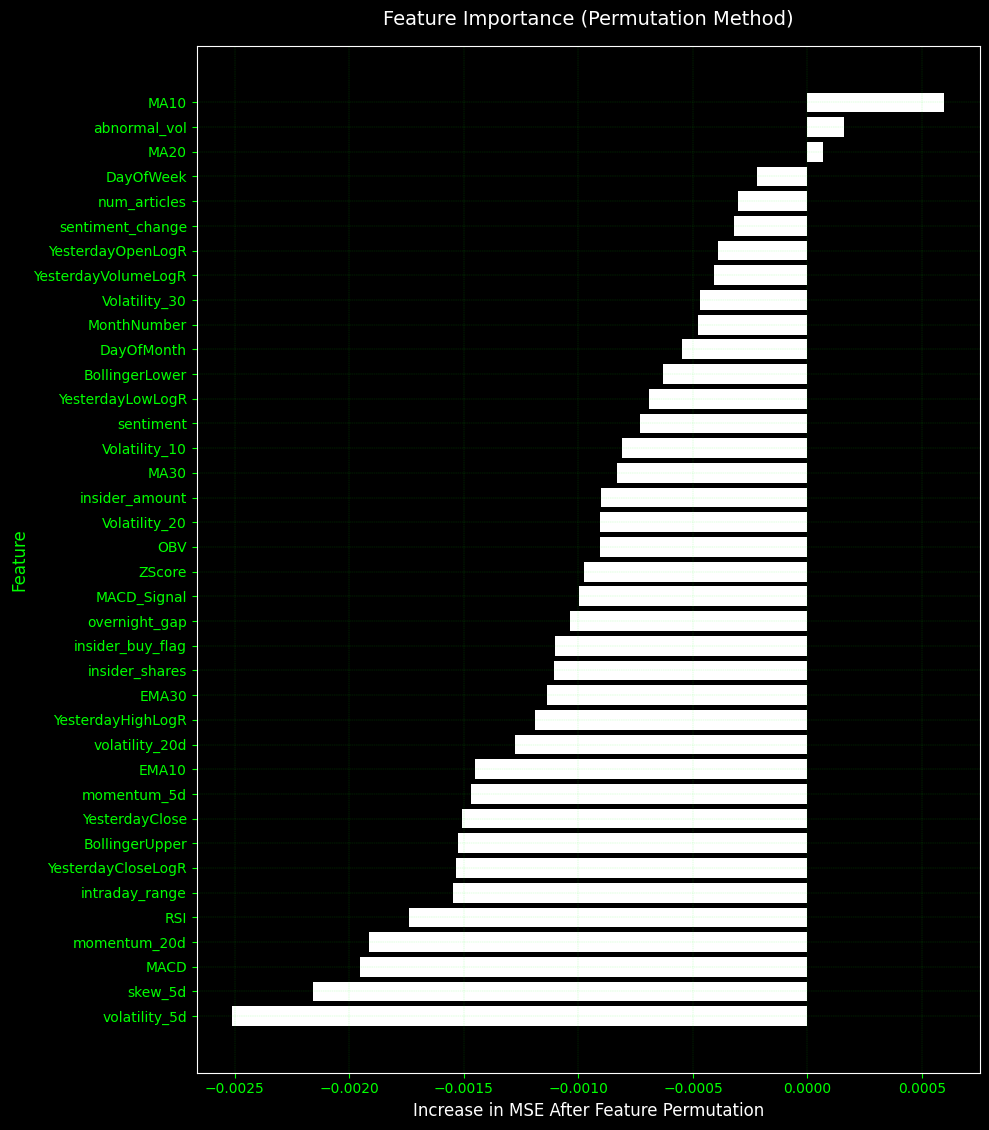

In [ ]:
batch = val_gen[0]
if isinstance(batch, tuple):
    if len(batch) == 2:
        X_val, y_val = batch
    elif len(batch) == 3:
        X_val, y_val, _ = batch  # ignore sample weights
    else:
        raise ValueError(f"Unexpected number of outputs: {len(batch)}")
else:
    raise ValueError("val_gen[0] did not return a tuple.")
importance_df = feature_importance(model, X_val, y_val, feature_cols)

#Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))  # dynamically scale height

ax.barh(importance_df["Feature"], importance_df["Importance"], color="white", linewidth=1.2)
ax.set_xlabel("Increase in MSE After Feature Permutation", fontsize=12)
ax.set_ylabel("Feature", color="lime", fontsize=12)
ax.set_title("Feature Importance (Permutation Method)", fontsize=14, pad=15)

# Customize tick labels
ax.tick_params(axis='x', colors='lime')
ax.tick_params(axis='y', colors='lime')

# Optional grid styling
ax.grid(color='lime', linestyle='--', linewidth=0.3, alpha=0.3)

# Flip the order (so most important features at top)
plt.gca().invert_yaxis()


plt.tight_layout()
output_path = CONFIG["FORECAST_DIR"] / "feature_importance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
# Save as high-quality PNG


In [ ]:
# Forecasting 
for file in glob.glob(str(CONFIG["FORECAST_DIR"] / "*.csv")):
    os.remove(file)

print("Generating forecasts...")

for csv_path in all_csvs:
    stock_name = Path(csv_path).stem

    X_all, closes, pred_dates, df = process_stock_for_inference(Path(csv_path))

    # Skip if nothing to forecast
    if X_all.size == 0:
        continue

    # Create forecast dataframe
    forecast_df = make_forecast(
        model=model,
        X=X_all,
        dates=pred_dates,
        closes=closes,
        horizons=horizons,
        horizon_days=horizon_days
    )

    forecast_df.to_csv(CONFIG["FORECAST_DIR"] / f"{stock_name}_forecast.csv", index=False)
    print("Saved:", stock_name)

print("Done.")

Generating forecasts...
Saved: AACG_daily_processed
Saved: AAL_daily_processed
Saved: AAME_daily_processed
Saved: AAMI_daily_processed
Saved: AAOI_daily_processed
Saved: AAON_daily_processed
Saved: AAPL_daily_processed
Saved: AAP_daily_processed
Saved: AAT_daily_processed
Saved: AA_daily_processed
Saved: ABBV_daily_processed
Saved: ABCB_daily_processed
Saved: ABCL_daily_processed
Saved: ABEO_daily_processed
Saved: ABEV_daily_processed
Saved: ABG_daily_processed
Saved: ABL_daily_processed
Saved: ABM_daily_processed
Saved: ABNB_daily_processed
Saved: ABOS_daily_processed
Saved: ABR_daily_processed
Saved: ABSI_daily_processed
Saved: ABTS_daily_processed
Saved: ABT_daily_processed
Saved: ABUS_daily_processed
Saved: ABVC_daily_processed
Saved: AB_daily_processed
Saved: ACAD_daily_processed
Saved: ACA_daily_processed
Saved: ACB_daily_processed
Saved: ACCO_daily_processed
Saved: ACCS_daily_processed
Saved: ACEL_daily_processed
Saved: ACET_daily_processed
Saved: ACGLN_daily_processed
Saved: AC